所有图表将保存到: F:\Dissertation\picts\cuasmrl_analysis

绘制mm_leakyrelu训练曲线...
图表已保存到: F:\Dissertation\picts\cuasmrl_analysis\mm_leakyrelu_training_curve.pdf


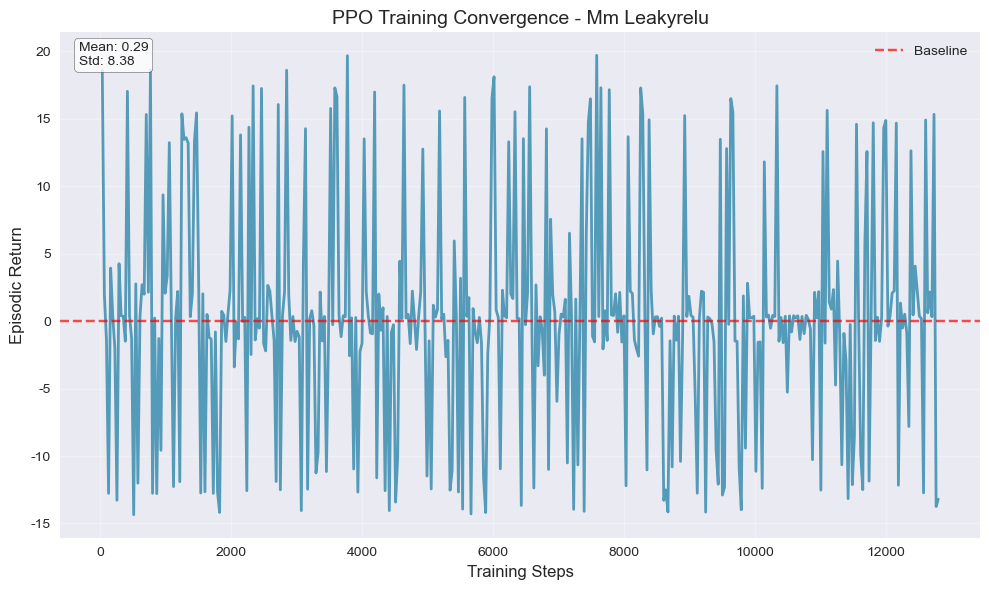


mm_leakyrelu 训练分析:
平均奖励: 0.290
标准差: 8.376
最大值: 19.715
最小值: -14.349
最终50步平均: 0.080

绘制所有核函数训练曲线...
图表已保存到: F:\Dissertation\picts\cuasmrl_analysis\all_kernels_training_curves.pdf


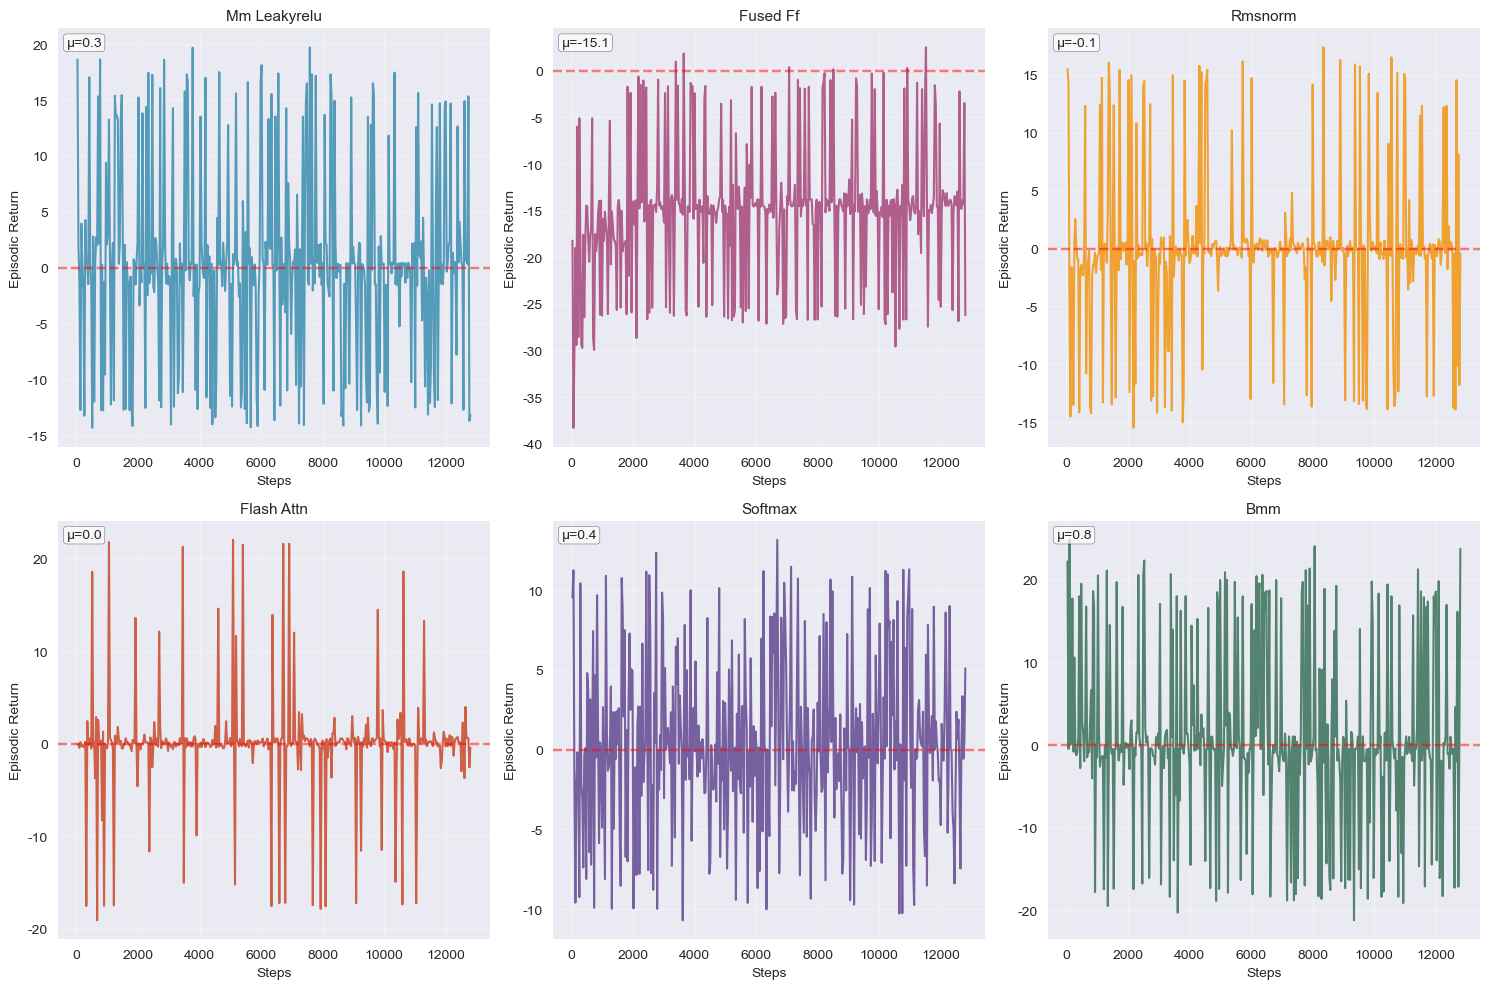

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

# 设置保存路径
SAVE_DIR = r'F:\Dissertation\picts\cuasmrl_analysis'

# 创建保存目录（如果不存在）
os.makedirs(SAVE_DIR, exist_ok=True)

# 设置中文字体和样式
plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
plt.style.use('seaborn-v0_8')

# 文件映射 - 根据实际文件名修正
files = {
    'mm_leakyrelu': os.path.join(SAVE_DIR, 'NVIDIA_A100-SXM4-80GB_mm_leakyRelu_512_512_2048.csv'),
    'fused_ff': os.path.join(SAVE_DIR, 'NVIDIA_A100-SXM4-80GB_fused_ff_1_512_512_1024.csv'), 
    'rmsnorm': os.path.join(SAVE_DIR, 'NVIDIA_A100-SXM4-80GB_rmsnorm_1_32_4096_64.csv'),
    'flash_attn': os.path.join(SAVE_DIR, 'NVIDIA_A100-SXM4-80GB_flash_attn_1_4_4096_32_False.csv'),
    'softmax': os.path.join(SAVE_DIR, 'NVIDIA_A100-SXM4-80GB_persistent_softmax_512_4096.csv'),
    'bmm': os.path.join(SAVE_DIR, 'NVIDIA_A100-SXM4-80GB_bmm_2_512_512_2048.csv')
}

# 方案1: 只显示mm_leakyrelu（推荐用于论文）
def plot_single_kernel(kernel_name='mm_leakyrelu'):
    """绘制单个核函数的训练曲线"""
    df = pd.read_csv(files[kernel_name])
    
    plt.figure(figsize=(10, 6))
    plt.plot(df['Step'], df['Value'], linewidth=2, alpha=0.8, color='#2E86AB')
    plt.axhline(y=0, color='red', linestyle='--', alpha=0.7, label='Baseline')
    
    plt.xlabel('Training Steps', fontsize=12)
    plt.ylabel('Episodic Return', fontsize=12)
    plt.title(f'PPO Training Convergence - {kernel_name.replace("_", " ").title()}', fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.legend()
    
    # 添加统计信息
    mean_reward = df['Value'].mean()
    std_reward = df['Value'].std()
    plt.text(0.02, 0.98, f'Mean: {mean_reward:.2f}\nStd: {std_reward:.2f}', 
             transform=plt.gca().transAxes, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    plt.tight_layout()
    
    # 保存到指定目录
    save_path = os.path.join(SAVE_DIR, f'{kernel_name}_training_curve.pdf')
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"图表已保存到: {save_path}")
    
    plt.show()
    
    # 打印训练分析
    print(f"\n{kernel_name} 训练分析:")
    print(f"平均奖励: {mean_reward:.3f}")
    print(f"标准差: {std_reward:.3f}")
    print(f"最大值: {df['Value'].max():.3f}")
    print(f"最小值: {df['Value'].min():.3f}")
    print(f"最终50步平均: {df['Value'].tail(50).mean():.3f}")

# 方案2: 显示所有6个核函数（用于完整分析）
def plot_all_kernels():
    """绘制所有核函数的训练曲线"""
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()
    
    colors = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#593E8B', '#2D6A4F']
    
    for i, (kernel_name, filename) in enumerate(files.items()):
        df = pd.read_csv(filename)
        
        axes[i].plot(df['Step'], df['Value'], linewidth=1.5, 
                    alpha=0.8, color=colors[i])
        axes[i].axhline(y=0, color='red', linestyle='--', alpha=0.5)
        axes[i].set_title(kernel_name.replace('_', ' ').title(), fontsize=11)
        axes[i].set_xlabel('Steps', fontsize=10)
        axes[i].set_ylabel('Episodic Return', fontsize=10)
        axes[i].grid(True, alpha=0.3)
        
        # 添加统计信息
        mean_val = df['Value'].mean()
        axes[i].text(0.02, 0.98, f'μ={mean_val:.1f}', 
                    transform=axes[i].transAxes, verticalalignment='top',
                    bbox=dict(boxstyle='round', facecolor='white', alpha=0.7, pad=0.2))
    
    plt.tight_layout()
    
    # 保存到指定目录
    save_path = os.path.join(SAVE_DIR, 'all_kernels_training_curves.pdf')
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"图表已保存到: {save_path}")
    
    plt.show()

# 方案3: 比较最好和最差的核函数
def plot_comparison():
    """比较表现最好和最差的核函数"""
    # 根据之前的箱线图分析，选择有代表性的两个
    kernels_to_compare = ['mm_leakyrelu', 'rmsnorm']
    colors = ['#2E86AB', '#C73E1D']
    labels = ['MM LeakyReLU (Best)', 'RMSNorm (Worst)']
    
    plt.figure(figsize=(12, 6))
    
    for i, kernel in enumerate(kernels_to_compare):
        df = pd.read_csv(files[kernel])
        plt.plot(df['Step'], df['Value'], linewidth=2, 
                alpha=0.8, color=colors[i], label=labels[i])
    
    plt.axhline(y=0, color='red', linestyle='--', alpha=0.7, label='Baseline')
    plt.xlabel('Training Steps', fontsize=12)
    plt.ylabel('Episodic Return', fontsize=12)
    plt.title('PPO Training Convergence Comparison', fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    
    # 保存到指定目录
    save_path = os.path.join(SAVE_DIR, 'training_comparison.pdf')
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"图表已保存到: {save_path}")
    
    plt.show()

# 方案4: 显示训练不稳定性的统计分析
def analyze_training_instability():
    """分析所有核函数的训练不稳定性"""
    results = {}
    
    for kernel_name, filename in files.items():
        df = pd.read_csv(filename)
        
        # 计算滑动窗口的标准差来衡量不稳定性
        window_size = 20
        rolling_std = df['Value'].rolling(window=window_size).std()
        
        results[kernel_name] = {
            'mean_reward': df['Value'].mean(),
            'std_reward': df['Value'].std(),
            'mean_instability': rolling_std.mean(),
            'final_performance': df['Value'].tail(50).mean(),
            'improvement': df['Value'].tail(50).mean() - df['Value'].head(50).mean()
        }
    
    # 创建汇总表
    summary_df = pd.DataFrame(results).T
    print("训练稳定性分析:")
    print(summary_df.round(3))
    
    # 保存分析结果到CSV
    csv_path = os.path.join(SAVE_DIR, 'training_stability_analysis.csv')
    summary_df.round(3).to_csv(csv_path)
    print(f"分析结果已保存到: {csv_path}")
    
    return summary_df

# 使用示例
if __name__ == "__main__":
    print(f"所有图表将保存到: {SAVE_DIR}")
    
    # 为论文推荐使用方案1
    print("\n绘制mm_leakyrelu训练曲线...")
    plot_single_kernel('mm_leakyrelu')
    
    # 如果需要完整分析，可以运行：
    print("\n绘制所有核函数训练曲线...")
    plot_all_kernels()
    
    # print("\n绘制对比图...")
    # plot_comparison()
    
    # print("\n分析训练稳定性...")
    # analyze_training_instability()

所有Policy Loss图表将保存到: F:\Dissertation\picts\cuasmrl_analysis

绘制所有核函数Policy Loss曲线...
所有Policy Loss图表已保存到: F:\Dissertation\picts\cuasmrl_analysis\all_kernels_policy_loss.pdf


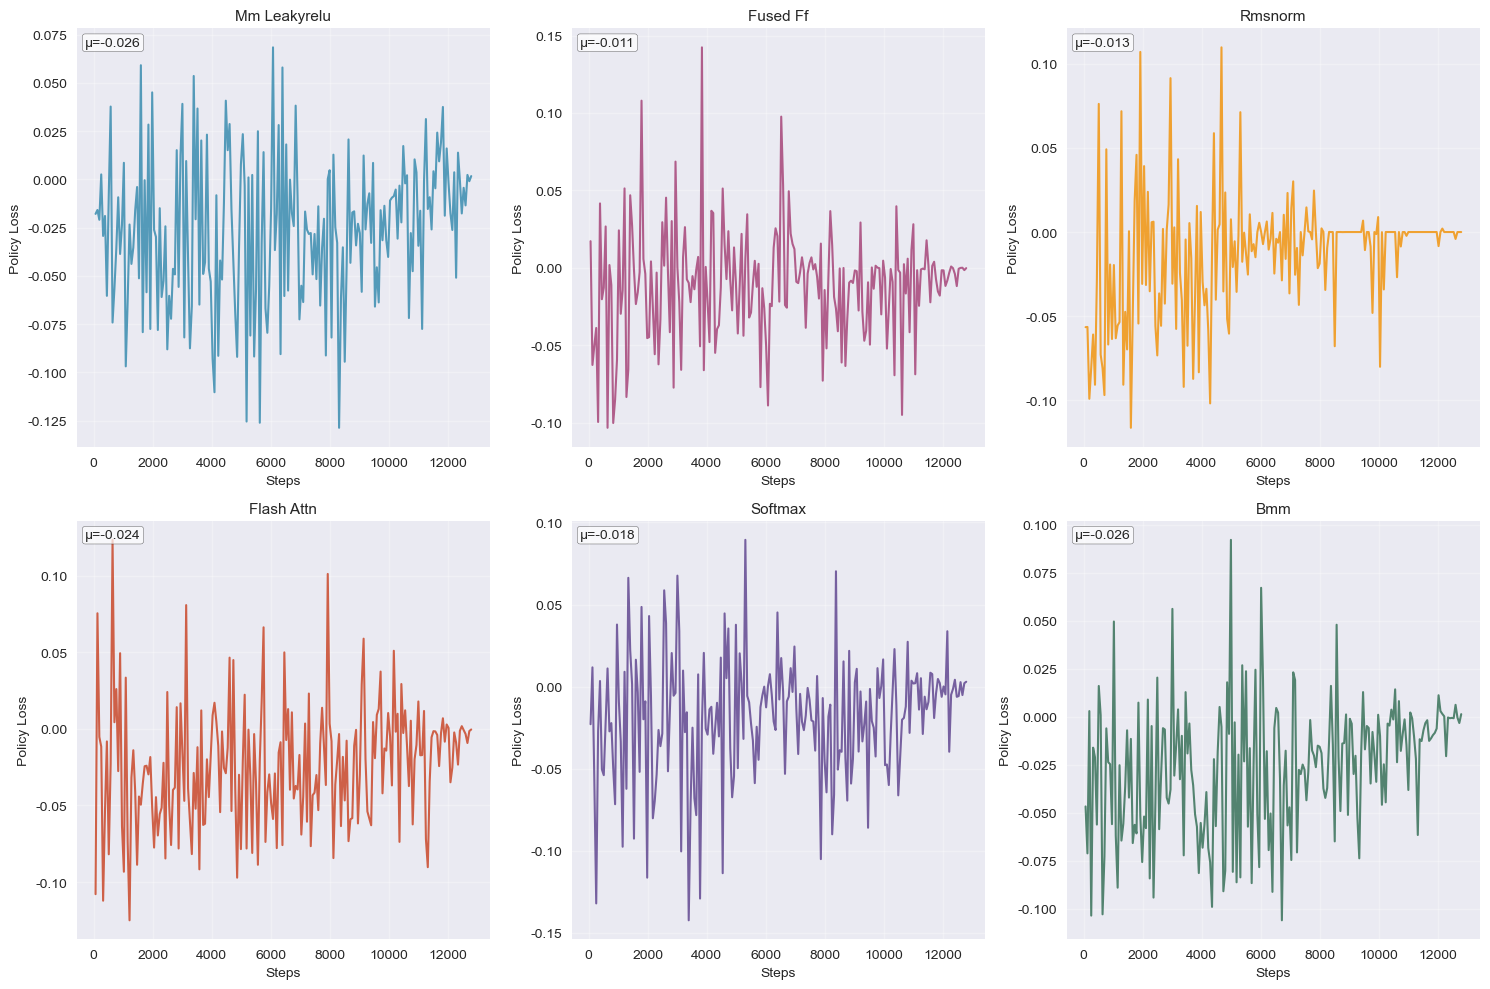

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

# 设置保存路径
SAVE_DIR = r'F:\Dissertation\picts\cuasmrl_analysis'

# 创建保存目录（如果不存在）
os.makedirs(SAVE_DIR, exist_ok=True)

# 设置中文字体和样式
plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
plt.style.use('seaborn-v0_8')

# Policy Loss文件映射
policy_loss_files = {
    'mm_leakyrelu': os.path.join(SAVE_DIR, 'policy_loss', 'NVIDIA_A100-SXM4-80GB_mm_leakyRelu_512_512_2048(1).csv'),
    'fused_ff': os.path.join(SAVE_DIR, 'policy_loss', 'NVIDIA_A100-SXM4-80GB_fused_ff_1_512_512_1024(1).csv'), 
    'rmsnorm': os.path.join(SAVE_DIR, 'policy_loss', 'NVIDIA_A100-SXM4-80GB_rmsnorm_1_32_4096_64(1).csv'),
    'flash_attn': os.path.join(SAVE_DIR, 'policy_loss', 'NVIDIA_A100-SXM4-80GB_flash_attn_1_4_4096_32_False(1).csv'),
    'softmax': os.path.join(SAVE_DIR, 'policy_loss', 'NVIDIA_A100-SXM4-80GB_persistent_softmax_512_4096(1).csv'),
    'bmm': os.path.join(SAVE_DIR, 'policy_loss', 'NVIDIA_A100-SXM4-80GB_bmm_2_512_512_2048(1).csv')
}

# 方案1: 只显示mm_leakyrelu的policy loss（推荐用于论文）
def plot_single_policy_loss(kernel_name='mm_leakyrelu'):
    """绘制单个核函数的Policy Loss曲线"""
    df = pd.read_csv(policy_loss_files[kernel_name])
    
    plt.figure(figsize=(10, 6))
    plt.plot(df['Step'], df['Value'], linewidth=2, alpha=0.8, color='#2E86AB')
    
    plt.xlabel('Training Steps', fontsize=12)
    plt.ylabel('Policy Loss', fontsize=12)
    plt.title(f'PPO Policy Loss - {kernel_name.replace("_", " ").title()}', fontsize=14)
    plt.grid(True, alpha=0.3)
    
    # 添加统计信息
    mean_loss = df['Value'].mean()
    std_loss = df['Value'].std()
    final_loss = df['Value'].tail(50).mean()
    
    plt.text(0.02, 0.98, f'Mean: {mean_loss:.4f}\nStd: {std_loss:.4f}\nFinal 50: {final_loss:.4f}', 
             transform=plt.gca().transAxes, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    plt.tight_layout()
    
    # 保存到指定目录
    save_path = os.path.join(SAVE_DIR, f'{kernel_name}_policy_loss.pdf')
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"Policy Loss图表已保存到: {save_path}")
    
    plt.show()
    
    # 打印训练分析
    print(f"\n{kernel_name} Policy Loss分析:")
    print(f"平均损失: {mean_loss:.6f}")
    print(f"标准差: {std_loss:.6f}")
    print(f"最大值: {df['Value'].max():.6f}")
    print(f"最小值: {df['Value'].min():.6f}")
    print(f"最终50步平均: {final_loss:.6f}")
    print(f"损失变化趋势: {'改善' if final_loss < mean_loss else '恶化'}")

# 方案2: 显示所有6个核函数的policy loss
def plot_all_policy_losses():
    """绘制所有核函数的Policy Loss曲线"""
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()
    
    colors = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#593E8B', '#2D6A4F']
    
    for i, (kernel_name, filename) in enumerate(policy_loss_files.items()):
        try:
            df = pd.read_csv(filename)
            
            axes[i].plot(df['Step'], df['Value'], linewidth=1.5, 
                        alpha=0.8, color=colors[i])
            axes[i].set_title(kernel_name.replace('_', ' ').title(), fontsize=11)
            axes[i].set_xlabel('Steps', fontsize=10)
            axes[i].set_ylabel('Policy Loss', fontsize=10)
            axes[i].grid(True, alpha=0.3)
            
            # 添加统计信息
            mean_val = df['Value'].mean()
            axes[i].text(0.02, 0.98, f'μ={mean_val:.3f}', 
                        transform=axes[i].transAxes, verticalalignment='top',
                        bbox=dict(boxstyle='round', facecolor='white', alpha=0.7, pad=0.2))
        except FileNotFoundError:
            axes[i].text(0.5, 0.5, 'File Not Found', ha='center', va='center',
                        transform=axes[i].transAxes, fontsize=12)
            axes[i].set_title(f'{kernel_name} - Missing', fontsize=11)
    
    plt.tight_layout()
    
    # 保存到指定目录
    save_path = os.path.join(SAVE_DIR, 'all_kernels_policy_loss.pdf')
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"所有Policy Loss图表已保存到: {save_path}")
    
    plt.show()

# 方案3: 比较Episodic Return vs Policy Loss
def plot_return_vs_policy_loss(kernel_name='mm_leakyrelu'):
    """比较同一核函数的Episodic Return和Policy Loss"""
    # 读取episodic return数据
    episodic_return_path = os.path.join(SAVE_DIR, f'NVIDIA_A100-SXM4-80GB_{kernel_name}_512_512_2048.csv')
    if kernel_name == 'fused_ff':
        episodic_return_path = os.path.join(SAVE_DIR, f'NVIDIA_A100-SXM4-80GB_{kernel_name}_1_512_512_1024.csv')
    elif kernel_name == 'rmsnorm':
        episodic_return_path = os.path.join(SAVE_DIR, f'NVIDIA_A100-SXM4-80GB_{kernel_name}_1_32_4096_64.csv')
    elif kernel_name == 'flash_attn':
        episodic_return_path = os.path.join(SAVE_DIR, f'NVIDIA_A100-SXM4-80GB_{kernel_name}_1_4_4096_32_False.csv')
    elif kernel_name == 'softmax':
        episodic_return_path = os.path.join(SAVE_DIR, f'NVIDIA_A100-SXM4-80GB_persistent_{kernel_name}_512_4096.csv')
    elif kernel_name == 'bmm':
        episodic_return_path = os.path.join(SAVE_DIR, f'NVIDIA_A100-SXM4-80GB_{kernel_name}_2_512_512_2048.csv')
    
    df_return = pd.read_csv(episodic_return_path)
    df_loss = pd.read_csv(policy_loss_files[kernel_name])
    
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
    
    # 绘制Episodic Return
    ax1.plot(df_return['Step'], df_return['Value'], linewidth=2, 
             alpha=0.8, color='#2E86AB', label='Episodic Return')
    ax1.axhline(y=0, color='red', linestyle='--', alpha=0.5)
    ax1.set_ylabel('Episodic Return', fontsize=12)
    ax1.grid(True, alpha=0.3)
    ax1.legend()
    
    # 绘制Policy Loss
    ax2.plot(df_loss['Step'], df_loss['Value'], linewidth=2, 
             alpha=0.8, color='#2E86AB', label='Policy Loss')
    ax2.set_xlabel('Training Steps', fontsize=12)
    ax2.set_ylabel('Policy Loss', fontsize=12)
    ax2.grid(True, alpha=0.3)
    ax2.legend()
    
    plt.suptitle(f'Training Progress Comparison - {kernel_name.replace("_", " ").title()}', fontsize=14)
    plt.tight_layout()
    
    # 保存到指定目录
    save_path = os.path.join(SAVE_DIR, f'{kernel_name}_return_vs_loss.pdf')
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"对比图表已保存到: {save_path}")
    
    plt.show()

# 方案4: 分析Policy Loss的收敛性
def analyze_policy_loss_convergence():
    """分析所有核函数的Policy Loss收敛性"""
    results = {}
    
    for kernel_name, filename in policy_loss_files.items():
        try:
            df = pd.read_csv(filename)
            
            # 计算收敛性指标
            initial_loss = df['Value'].head(50).mean()
            final_loss = df['Value'].tail(50).mean()
            improvement = initial_loss - final_loss
            improvement_pct = (improvement / abs(initial_loss)) * 100 if initial_loss != 0 else 0
            
            # 计算稳定性指标
            window_size = 20
            rolling_std = df['Value'].rolling(window=window_size).std()
            
            results[kernel_name] = {
                'initial_loss': initial_loss,
                'final_loss': final_loss,
                'improvement': improvement,
                'improvement_pct': improvement_pct,
                'mean_loss': df['Value'].mean(),
                'std_loss': df['Value'].std(),
                'mean_instability': rolling_std.mean()
            }
        except FileNotFoundError:
            print(f"警告: 未找到 {kernel_name} 的policy loss文件")
            continue
    
    if results:
        # 创建汇总表
        summary_df = pd.DataFrame(results).T
        print("Policy Loss收敛性分析:")
        print(summary_df.round(6))
        
        # 保存分析结果到CSV
        csv_path = os.path.join(SAVE_DIR, 'policy_loss_convergence_analysis.csv')
        summary_df.round(6).to_csv(csv_path)
        print(f"Policy Loss分析结果已保存到: {csv_path}")
        
        return summary_df
    else:
        print("没有找到任何Policy Loss文件进行分析")
        return None

# 使用示例
if __name__ == "__main__":
    print(f"所有Policy Loss图表将保存到: {SAVE_DIR}")
    
    # 为论文推荐使用方案1
    # print("\n绘制mm_leakyrelu的Policy Loss曲线...")
    # plot_single_policy_loss('mm_leakyrelu')
    
    # 如果需要完整分析，可以运行：
    print("\n绘制所有核函数Policy Loss曲线...")
    plot_all_policy_losses()
    
    # print("\n绘制Return vs Policy Loss对比图...")
    # plot_return_vs_policy_loss('mm_leakyrelu')
    
    # print("\n分析Policy Loss收敛性...")
    # analyze_policy_loss_convergence()

Figure saved to: F:\Dissertation\picts\cuasmrl_analysis\ppo_vs_uniform_comparison.pdf


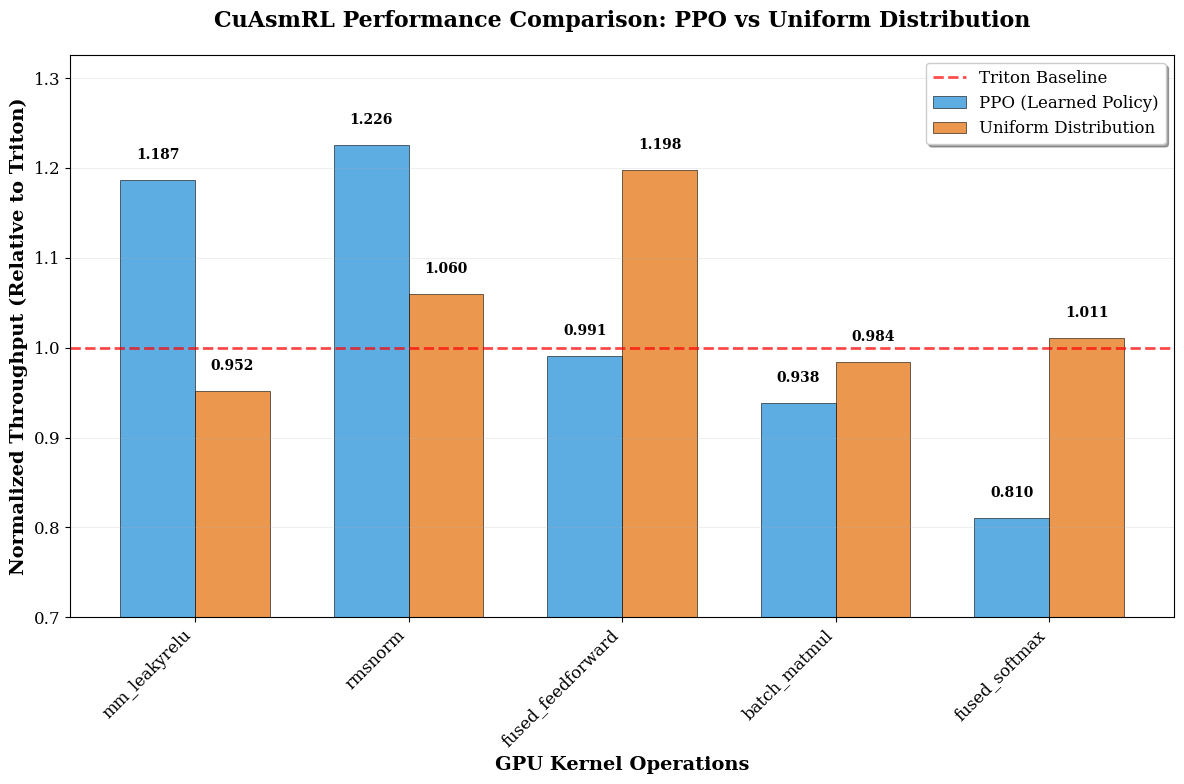


=== PPO vs Uniform Distribution Comparison ===
PPO average improvement: 3.0%
Uniform distribution average improvement: 4.1%
Performance difference: 1.1 percentage points

=== Kernel-wise Performance Analysis ===
mm_leakyrelu: PPO +18.7%, Uniform -4.8% → PPO wins by 23.5pp
rmsnorm: PPO +22.6%, Uniform +6.0% → PPO wins by 16.6pp
fused_feedforward: PPO -0.9%, Uniform +19.8% → Uniform wins by 20.7pp
batch_matmul: PPO -6.2%, Uniform -1.6% → Uniform wins by 4.6pp
fused_softmax: PPO -19.0%, Uniform +1.1% → Uniform wins by 20.1pp

Summary: PPO wins 2/5 kernels, Uniform wins 3/5 kernels


In [7]:
import matplotlib.pyplot as plt
import numpy as np

def plot_ppo_vs_uniform_comparison(save_path=None):
    """
    Plot CuAsmRL performance comparison: PPO vs Uniform Distribution
    
    Parameters:
    save_path (str): Path to save the figure, e.g., 'ppo_vs_uniform_comparison.pdf'
    """
    
    # Data: PPO results vs Uniform Distribution results
    # PPO results (first dataset - trained with PPO)
    ppo_data = {
        'mm_leakyrelu': 1.187,      # +18.7% improvement
        'rmsnorm': 1.226,           # +22.6% improvement  
        'fused_feedforward': 0.991, # -0.9% (slower than Triton)
        'batch_matmul': 0.938,      # -6.2% (slower than Triton)
        'fused_softmax': 0.810,     # -19.0% (slower than Triton)
    }
    
    # Uniform distribution results (second dataset - uniform action selection)
    uniform_data = {
        'mm_leakyrelu': 0.952,      # -4.8% (slower than Triton)
        'rmsnorm': 1.060,           # +6.0% improvement
        'fused_feedforward': 1.198, # +19.8% improvement  
        'batch_matmul': 0.984,      # -1.6% (slower than Triton)
        'fused_softmax': 1.011,     # +1.1% improvement
    }
    
    # Prepare data for plotting
    kernels = list(ppo_data.keys())
    ppo_values = list(ppo_data.values())
    uniform_values = list(uniform_data.values())
    
    # Set figure parameters
    plt.figure(figsize=(12, 8))
    plt.rcParams['font.size'] = 12
    plt.rcParams['font.family'] = 'serif'
    
    # Set bar positions
    x = np.arange(len(kernels))
    width = 0.35
    
    # Create bar plots
    bars1 = plt.bar(x - width/2, ppo_values, width, 
                   label='PPO (Learned Policy)', 
                   color='#3498db', alpha=0.8, edgecolor='black', linewidth=0.5)
    
    bars2 = plt.bar(x + width/2, uniform_values, width,
                   label='Uniform Distribution', 
                   color='#e67e22', alpha=0.8, edgecolor='black', linewidth=0.5)
    
    # Add baseline reference line
    plt.axhline(y=1.0, color='red', linestyle='--', linewidth=2, 
                alpha=0.7, label='Triton Baseline')
    
    # Set labels and title
    plt.xlabel('GPU Kernel Operations', fontsize=14, fontweight='bold')
    plt.ylabel('Normalized Throughput (Relative to Triton)', fontsize=14, fontweight='bold')
    plt.title('CuAsmRL Performance Comparison: PPO vs Uniform Distribution', 
              fontsize=16, fontweight='bold', pad=20)
    
    # Set x-axis labels
    plt.xticks(x, kernels, rotation=45, ha='right')
    
    # Set y-axis range and ticks
    y_min = 0.7
    y_max = max(max(ppo_values), max(uniform_values)) + 0.1
    plt.ylim(y_min, y_max)
    
    # Create appropriate y-ticks
    y_ticks = np.arange(0.7, y_max + 0.01, 0.1)
    plt.yticks(y_ticks, [f'{y:.1f}' for y in y_ticks])
    
    # Add value labels on bars
    def add_value_labels(bars, values, offset=0.02):
        for bar, value in zip(bars, values):
            height = bar.get_height()
            plt.text(bar.get_x() + bar.get_width()/2., height + offset,
                    f'{value:.3f}',
                    ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    add_value_labels(bars1, ppo_values, offset=0.02)
    add_value_labels(bars2, uniform_values, offset=0.02)
    
    # Add legend
    plt.legend(loc='upper right', frameon=True, shadow=True)
    
    # Add grid
    plt.grid(True, axis='y', alpha=0.3, linestyle='-', linewidth=0.5)
    
    # Adjust layout
    plt.tight_layout()
    
    # Save figure
    if save_path:
        import os
        
        # Set save directory
        save_dir = r'F:\Dissertation\picts\cuasmrl_analysis'
        os.makedirs(save_dir, exist_ok=True)
        
        # Get filename
        filename = os.path.basename(save_path)
        
        # Ensure PDF format
        if not filename.endswith('.pdf'):
            filename = filename.rsplit('.', 1)[0] + '.pdf'
        
        # Build full save path
        full_save_path = os.path.join(save_dir, filename)
        
        plt.savefig(full_save_path, dpi=300, bbox_inches='tight', 
                    facecolor='white', edgecolor='none',
                    format='pdf')
        print(f"Figure saved to: {full_save_path}")
    
    # Show figure
    plt.show()
    
    # Calculate statistics
    ppo_avg_improvement = np.mean([(v - 1.0) * 100 for v in ppo_values])
    uniform_avg_improvement = np.mean([(v - 1.0) * 100 for v in uniform_values])
    
    print("\n=== PPO vs Uniform Distribution Comparison ===")
    print(f"PPO average improvement: {ppo_avg_improvement:.1f}%")
    print(f"Uniform distribution average improvement: {uniform_avg_improvement:.1f}%")
    print(f"Performance difference: {uniform_avg_improvement - ppo_avg_improvement:.1f} percentage points")
    
    # Kernel-wise comparison
    print("\n=== Kernel-wise Performance Analysis ===")
    ppo_better = 0
    uniform_better = 0
    
    for i, kernel in enumerate(kernels):
        ppo_imp = (ppo_values[i] - 1) * 100
        uniform_imp = (uniform_values[i] - 1) * 100
        diff = uniform_imp - ppo_imp
        
        if ppo_imp > uniform_imp:
            winner = "PPO"
            ppo_better += 1
        else:
            winner = "Uniform"
            uniform_better += 1
            
        print(f"{kernel}: PPO {ppo_imp:+.1f}%, Uniform {uniform_imp:+.1f}% → {winner} wins by {abs(diff):.1f}pp")
    
    print(f"\nSummary: PPO wins {ppo_better}/5 kernels, Uniform wins {uniform_better}/5 kernels")
    
    # Return data for further analysis
    return {
        'kernels': kernels,
        'ppo_values': ppo_values,
        'uniform_values': uniform_values,
        'ppo_avg_improvement': ppo_avg_improvement,
        'uniform_avg_improvement': uniform_avg_improvement
    }

# Usage
if __name__ == "__main__":
    # Plot PPO vs Uniform comparison
    results = plot_ppo_vs_uniform_comparison(save_path='ppo_vs_uniform_comparison.pdf')

Corrected grouped boxplot saved to: F:\Dissertation\picts\cuasmrl_analysis\corrected_ppo_uniform_boxplot.pdf


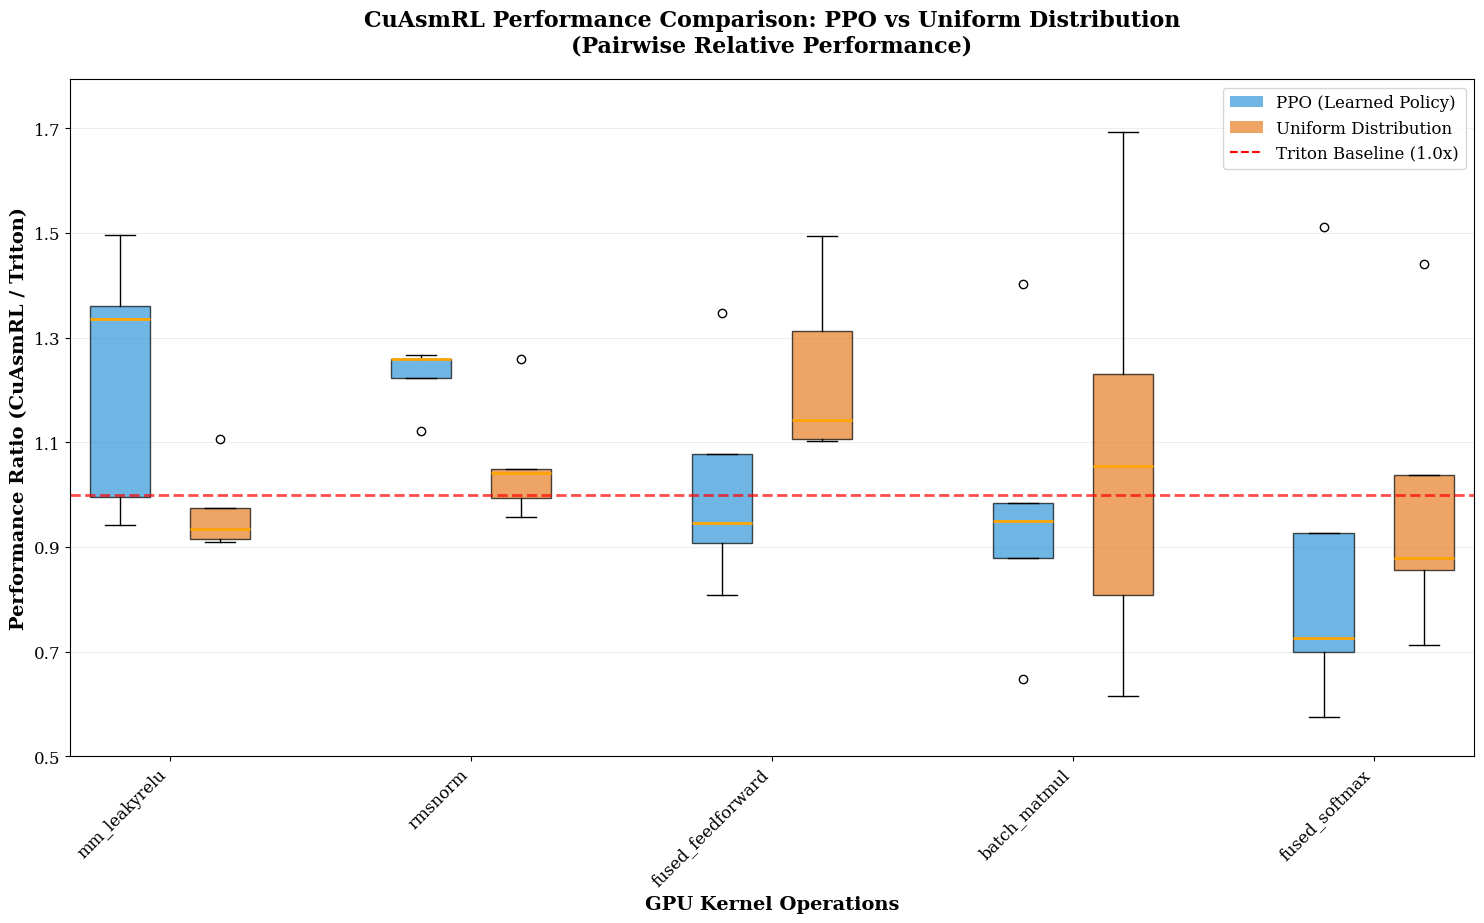


=== PPO vs Uniform Distribution Performance Analysis (Pairwise Comparison) ===
Kernel               PPO Median   Uniform Median  PPO Range            Uniform Range        Winner
--------------------------------------------------------------------------------------------------------------
mm_leakyrelu         1.335        0.934           0.941-1.496          0.909-1.106          PPO
rmsnorm              1.259        1.041           1.122-1.267          0.957-1.258          PPO
fused_feedforward    0.946        1.142           0.809-1.347          1.102-1.495          Uniform
batch_matmul         0.950        1.054           0.648-1.403          0.615-1.694          Uniform
fused_softmax        0.726        0.878           0.575-1.511          0.713-1.440          Uniform

Summary: PPO wins 2/5 kernels, Uniform wins 3/5 kernels

Overall Performance (Pairwise Comparison):
PPO average performance ratio: 1.066 (6.6% improvement)
Uniform average performance ratio: 1.065 (6.5% improvement)



In [17]:
import matplotlib.pyplot as plt
import numpy as np

def plot_corrected_grouped_boxplot_comparison(save_path=None):
    """
    Plot grouped boxplot comparison with correct pairwise relative performance calculation
    """
    
    # PPO performance data - each run's results
    triton_baseline_ppo = {
        'mm_leakyrelu': [11.72, 14.61, 12.57, 10.15, 19.97],
        'rmsnorm': [74.75, 72.90, 73.27, 72.88, 73.51],
        'fused_feedforward': [3.57, 5.21, 4.01, 4.92, 5.84],
        'batch_matmul': [19.89, 29.36, 30.54, 27.13, 32.15],
        'fused_softmax': [483.13, 551.52, 378.93, 434.56, 249.53],
    }
    
    cuasmrl_ppo_results = {
        'mm_leakyrelu': [15.94, 13.75, 18.80, 13.55, 19.88],      
        'rmsnorm': [91.43, 81.80, 92.30, 92.34, 92.53],      
        'fused_feedforward': [4.81, 4.93, 4.32, 3.98, 5.30],      
        'batch_matmul': [27.91, 28.91, 29.01, 23.82, 20.82],     
        'fused_softmax': [350.73, 316.86, 351.42, 303.53, 377.11],      
    }
    
    # Uniform Distribution performance data - each run's results
    triton_baseline_uniform = {
        'mm_leakyrelu': [38.995, 37.874, 21.923, 39.921, 17.982],
        'rmsnorm': [69.543, 72.656, 73.327, 73.173, 72.980],
        'fused_feedforward': [6.849, 8.747, 5.387, 8.318, 4.595],
        'batch_matmul': [54.303, 21.949, 43.592, 55.019, 47.706],
        'fused_softmax': [654.595, 414.127, 678.492, 531.237, 880.525],
    }
    
    cuasmrl_uniform_results = {
        'mm_leakyrelu': [35.704, 35.384, 24.247, 36.295, 17.517],
        'rmsnorm': [72.919, 72.156, 92.272, 76.160, 69.849],
        'fused_feedforward': [7.820, 9.637, 7.069, 9.203, 6.869],
        'batch_matmul': [33.423, 37.173, 53.679, 44.472, 50.291],
        'fused_softmax': [560.176, 363.674, 977.358, 379.003, 913.511],
    }
    
    # Calculate improvement ratios correctly - pairwise comparison
    common_kernels = ['mm_leakyrelu', 'rmsnorm', 'fused_feedforward', 'batch_matmul', 'fused_softmax']
    
    ppo_ratios = {}
    uniform_ratios = {}
    
    for kernel in common_kernels:
        # PPO ratios - each CuAsmRL result divided by corresponding Triton result
        triton_perfs = triton_baseline_ppo[kernel]
        cuasmrl_perfs = cuasmrl_ppo_results[kernel]
        ppo_ratios[kernel] = [cuasmrl_perfs[i] / triton_perfs[i] for i in range(len(cuasmrl_perfs))]
        
        # Uniform ratios - each CuAsmRL result divided by corresponding Triton result
        triton_perfs = triton_baseline_uniform[kernel]
        cuasmrl_perfs = cuasmrl_uniform_results[kernel]
        uniform_ratios[kernel] = [cuasmrl_perfs[i] / triton_perfs[i] for i in range(len(cuasmrl_perfs))]
    
    # Create single figure with grouped boxplots
    plt.figure(figsize=(15, 9))
    plt.rcParams['font.size'] = 12
    plt.rcParams['font.family'] = 'serif'
    
    # Prepare data for grouped boxplot
    num_kernels = len(common_kernels)
    positions_ppo = np.arange(1, num_kernels * 3, 3)  # 1, 4, 7, 10, 13
    positions_uniform = np.arange(2, num_kernels * 3 + 1, 3)  # 2, 5, 8, 11, 14
    
    # Create PPO boxplots
    data_to_plot_ppo = [ppo_ratios[kernel] for kernel in common_kernels]
    box_plot_ppo = plt.boxplot(data_to_plot_ppo, positions=positions_ppo, 
                               patch_artist=True, widths=0.6, 
                               boxprops=dict(facecolor='#3498db', alpha=0.7),
                               medianprops=dict(color='orange', linewidth=2))
    
    # Create Uniform boxplots
    data_to_plot_uniform = [uniform_ratios[kernel] for kernel in common_kernels]
    box_plot_uniform = plt.boxplot(data_to_plot_uniform, positions=positions_uniform, 
                                   patch_artist=True, widths=0.6,
                                   boxprops=dict(facecolor='#e67e22', alpha=0.7),
                                   medianprops=dict(color='orange', linewidth=2))
    
    # Add baseline
    plt.axhline(y=1.0, color='red', linestyle='--', linewidth=2, 
                alpha=0.7, label='Triton Baseline (1.0x)')
    
    # Set labels and title
    plt.xlabel('GPU Kernel Operations', fontsize=14, fontweight='bold')
    plt.ylabel('Performance Ratio (CuAsmRL / Triton)', fontsize=14, fontweight='bold')
    plt.title('CuAsmRL Performance Comparison: PPO vs Uniform Distribution\n(Pairwise Relative Performance)', 
              fontsize=16, fontweight='bold', pad=20)
    
    # Set x-axis ticks and labels
    tick_positions = (positions_ppo + positions_uniform) / 2
    plt.xticks(tick_positions, common_kernels, rotation=45, ha='right')
    
    # Set y-axis range to show all data points clearly
    all_values = []
    for ratios in ppo_ratios.values():
        all_values.extend(ratios)
    for ratios in uniform_ratios.values():
        all_values.extend(ratios)
    
    y_min = min(all_values) - 0.05
    y_max = max(all_values) + 0.1
    plt.ylim(y_min, y_max)
    
    # Set y-axis ticks
    y_tick_spacing = 0.1 if (y_max - y_min) < 1.0 else 0.2
    y_ticks = np.arange(np.floor(y_min * 10) / 10, y_max + 0.01, y_tick_spacing)
    plt.yticks(y_ticks, [f'{tick:.1f}' for tick in y_ticks])
    
    # Add legend
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='#3498db', alpha=0.7, label='PPO (Learned Policy)'),
        Patch(facecolor='#e67e22', alpha=0.7, label='Uniform Distribution'),
        plt.Line2D([0], [0], color='red', linestyle='--', label='Triton Baseline (1.0x)')
    ]
    plt.legend(handles=legend_elements, loc='upper right')
    
    # Add grid
    plt.grid(True, axis='y', alpha=0.3, linestyle='-', linewidth=0.5)
    
    # Adjust layout
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.15)
    
    # Save figure
    if save_path:
        import os
        save_dir = r'F:\Dissertation\picts\cuasmrl_analysis'
        os.makedirs(save_dir, exist_ok=True)
        filename = os.path.basename(save_path)
        if not filename.endswith('.pdf'):
            filename = filename.rsplit('.', 1)[0] + '.pdf'
        full_save_path = os.path.join(save_dir, filename)
        plt.savefig(full_save_path, dpi=300, bbox_inches='tight', 
                   facecolor='white', edgecolor='none', format='pdf')
        print(f"Corrected grouped boxplot saved to: {full_save_path}")
    
    plt.show()
    
    # Print comparative statistics
    print("\n=== PPO vs Uniform Distribution Performance Analysis (Pairwise Comparison) ===")
    print(f"{'Kernel':<20} {'PPO Median':<12} {'Uniform Median':<15} {'PPO Range':<20} {'Uniform Range':<20} {'Winner'}")
    print("-" * 110)
    
    ppo_better = 0
    uniform_better = 0
    
    for kernel in common_kernels:
        ppo_median = np.median(ppo_ratios[kernel])
        uniform_median = np.median(uniform_ratios[kernel])
        ppo_range = f"{min(ppo_ratios[kernel]):.3f}-{max(ppo_ratios[kernel]):.3f}"
        uniform_range = f"{min(uniform_ratios[kernel]):.3f}-{max(uniform_ratios[kernel]):.3f}"
        
        if ppo_median > uniform_median:
            winner = "PPO"
            ppo_better += 1
        else:
            winner = "Uniform"
            uniform_better += 1
            
        print(f"{kernel:<20} {ppo_median:<12.3f} {uniform_median:<15.3f} {ppo_range:<20} {uniform_range:<20} {winner}")
    
    print(f"\nSummary: PPO wins {ppo_better}/{len(common_kernels)} kernels, Uniform wins {uniform_better}/{len(common_kernels)} kernels")
    
    # Overall averages
    ppo_overall_mean = np.mean([np.mean(ratios) for ratios in ppo_ratios.values()])
    uniform_overall_mean = np.mean([np.mean(ratios) for ratios in uniform_ratios.values()])
    
    print(f"\nOverall Performance (Pairwise Comparison):")
    print(f"PPO average performance ratio: {ppo_overall_mean:.3f} ({(ppo_overall_mean-1)*100:.1f}% improvement)")
    print(f"Uniform average performance ratio: {uniform_overall_mean:.3f} ({(uniform_overall_mean-1)*100:.1f}% improvement)")
    
    # Print individual run details for verification
    print(f"\n=== Detailed Pairwise Ratios ===")
    for kernel in common_kernels:
        print(f"\n{kernel}:")
        print(f"  PPO ratios: {[f'{r:.3f}' for r in ppo_ratios[kernel]]}")
        print(f"  Uniform ratios: {[f'{r:.3f}' for r in uniform_ratios[kernel]]}")
    
    return {
        'ppo_ratios': ppo_ratios,
        'uniform_ratios': uniform_ratios,
        'common_kernels': common_kernels,
        'ppo_overall_mean': ppo_overall_mean,
        'uniform_overall_mean': uniform_overall_mean
    }

# Usage
if __name__ == "__main__":
    results = plot_corrected_grouped_boxplot_comparison(save_path='corrected_ppo_uniform_boxplot.pdf')

<>:191: SyntaxWarning: invalid escape sequence '\D'
<>:191: SyntaxWarning: invalid escape sequence '\D'
C:\Users\lixin\AppData\Local\Temp\ipykernel_24352\883039055.py:191: SyntaxWarning: invalid escape sequence '\D'
  results = plot_cuasmrl_ppo_ga_comparison(save_path='F:\Dissertation\picts\ga\cuasmrl_ppo_ga_boxplot.pdf')


CuAsmRL PPO vs GA boxplot saved to: F:\Dissertation\picts\ga\cuasmrl_ppo_ga_boxplot.pdf


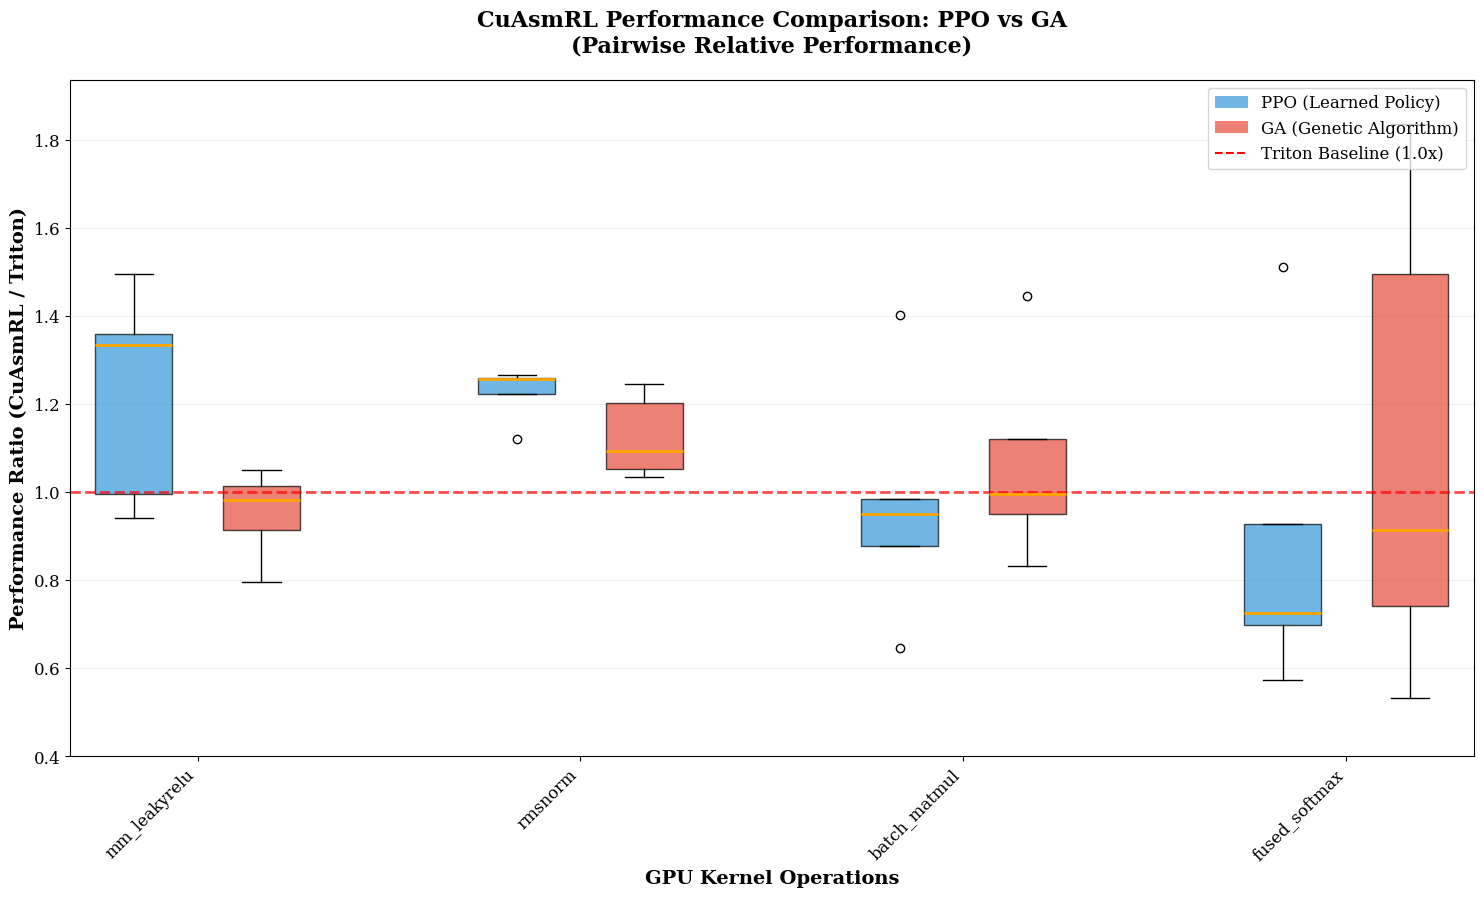


=== CuAsmRL PPO vs GA Performance Analysis (Pairwise Comparison) ===
Kernel               PPO Median   GA Median    PPO Range            GA Range             Winner
----------------------------------------------------------------------------------------------------
mm_leakyrelu         1.335        0.983        0.941-1.496          0.797-1.050          PPO
rmsnorm              1.259        1.093        1.122-1.267          1.035-1.246          PPO
batch_matmul         0.950        0.995        0.648-1.403          0.833-1.447          GA
fused_softmax        0.726        0.915        0.575-1.511          0.534-1.838          GA

Summary: PPO wins 2/4 kernels, GA wins 2/4 kernels

Overall Performance (Pairwise Comparison):
PPO average performance ratio: 1.078 (7.8% improvement)
GA average performance ratio: 1.063 (6.3% improvement)

=== Detailed Pairwise Ratios ===

mm_leakyrelu:
  PPO ratios: ['1.360', '0.941', '1.496', '1.335', '0.995']
  GA ratios: ['0.915', '1.015', '1.050', '0.797

In [2]:
import matplotlib.pyplot as plt
import numpy as np

def plot_cuasmrl_ppo_ga_comparison(save_path=None):
    """
    Plot grouped boxplot comparison between CuAsmRL PPO and GA performance
    using the four kernels available in GA data
    """
    
    # PPO performance data - each run's results (from the reference code)
    triton_baseline_ppo = {
        'mm_leakyrelu': [11.72, 14.61, 12.57, 10.15, 19.97],
        'rmsnorm': [74.75, 72.90, 73.27, 72.88, 73.51],
        'batch_matmul': [19.89, 29.36, 30.54, 27.13, 32.15],
        'fused_softmax': [483.13, 551.52, 378.93, 434.56, 249.53],
    }
    
    cuasmrl_ppo_results = {
        'mm_leakyrelu': [15.94, 13.75, 18.80, 13.55, 19.88],      
        'rmsnorm': [91.43, 81.80, 92.30, 92.34, 92.53],      
        'batch_matmul': [27.91, 28.91, 29.01, 23.82, 20.82],     
        'fused_softmax': [350.73, 316.86, 351.42, 303.53, 377.11],      
    }
    
    # GA performance data - from ga_inference2.log (matching kernels only)
    triton_baseline_ga = {
        'mm_leakyrelu': [14.871922, 16.018939, 12.301493, 15.161268, 11.877433],
        'rmsnorm': [72.797557, 83.912931, 72.656319, 73.326993, 73.285994],
        'batch_matmul': [26.945389, 19.703738, 21.280227, 21.021203, 27.583889],
        'fused_softmax': [596.505593, 267.673783, 232.077535, 370.884496, 352.181127],
    }
    
    ga_results = {
        'mm_leakyrelu': [13.606639, 16.266535, 12.919128, 12.085252, 11.677855],
        'rmsnorm': [75.317912, 91.72288, 87.41047, 77.283019, 91.291664],
        'batch_matmul': [25.643434, 19.614755, 30.791107, 23.593118, 22.975794],
        'fused_softmax': [318.535666, 491.891278, 347.291918, 275.421353, 322.144053],
    }
    
    # Calculate improvement ratios correctly - pairwise comparison
    common_kernels = ['mm_leakyrelu', 'rmsnorm', 'batch_matmul', 'fused_softmax']
    
    ppo_ratios = {}
    ga_ratios = {}
    
    for kernel in common_kernels:
        # PPO ratios - each CuAsmRL result divided by corresponding Triton result
        triton_perfs = triton_baseline_ppo[kernel]
        cuasmrl_perfs = cuasmrl_ppo_results[kernel]
        ppo_ratios[kernel] = [cuasmrl_perfs[i] / triton_perfs[i] for i in range(len(cuasmrl_perfs))]
        
        # GA ratios - each GA result divided by corresponding Triton result
        triton_perfs = triton_baseline_ga[kernel]
        ga_perfs = ga_results[kernel]
        ga_ratios[kernel] = [ga_perfs[i] / triton_perfs[i] for i in range(len(ga_perfs))]
    
    # Create single figure with grouped boxplots
    plt.figure(figsize=(15, 9))
    plt.rcParams['font.size'] = 12
    plt.rcParams['font.family'] = 'serif'
    
    # Prepare data for grouped boxplot
    num_kernels = len(common_kernels)
    positions_ppo = np.arange(1, num_kernels * 3, 3)  # 1, 4, 7, 10
    positions_ga = np.arange(2, num_kernels * 3 + 1, 3)  # 2, 5, 8, 11
    
    # Create PPO boxplots
    data_to_plot_ppo = [ppo_ratios[kernel] for kernel in common_kernels]
    box_plot_ppo = plt.boxplot(data_to_plot_ppo, positions=positions_ppo, 
                               patch_artist=True, widths=0.6, 
                               boxprops=dict(facecolor='#3498db', alpha=0.7),
                               medianprops=dict(color='orange', linewidth=2))
    
    # Create GA boxplots
    data_to_plot_ga = [ga_ratios[kernel] for kernel in common_kernels]
    box_plot_ga = plt.boxplot(data_to_plot_ga, positions=positions_ga, 
                              patch_artist=True, widths=0.6,
                              boxprops=dict(facecolor='#e74c3c', alpha=0.7),
                              medianprops=dict(color='orange', linewidth=2))
    
    # Add baseline
    plt.axhline(y=1.0, color='red', linestyle='--', linewidth=2, 
                alpha=0.7, label='Triton Baseline (1.0x)')
    
    # Set labels and title
    plt.xlabel('GPU Kernel Operations', fontsize=14, fontweight='bold')
    plt.ylabel('Performance Ratio (CuAsmRL / Triton)', fontsize=14, fontweight='bold')
    plt.title('CuAsmRL Performance Comparison: PPO vs GA\n(Pairwise Relative Performance)', 
              fontsize=16, fontweight='bold', pad=20)
    
    # Set x-axis ticks and labels
    tick_positions = (positions_ppo + positions_ga) / 2
    plt.xticks(tick_positions, common_kernels, rotation=45, ha='right')
    
    # Set y-axis range to show all data points clearly
    all_values = []
    for ratios in ppo_ratios.values():
        all_values.extend(ratios)
    for ratios in ga_ratios.values():
        all_values.extend(ratios)
    
    y_min = min(all_values) - 0.05
    y_max = max(all_values) + 0.1
    plt.ylim(y_min, y_max)
    
    # Set y-axis ticks
    y_tick_spacing = 0.1 if (y_max - y_min) < 1.0 else 0.2
    y_ticks = np.arange(np.floor(y_min * 10) / 10, y_max + 0.01, y_tick_spacing)
    plt.yticks(y_ticks, [f'{tick:.1f}' for tick in y_ticks])
    
    # Add legend
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='#3498db', alpha=0.7, label='PPO (Learned Policy)'),
        Patch(facecolor='#e74c3c', alpha=0.7, label='GA (Genetic Algorithm)'),
        plt.Line2D([0], [0], color='red', linestyle='--', label='Triton Baseline (1.0x)')
    ]
    plt.legend(handles=legend_elements, loc='upper right')
    
    # Add grid
    plt.grid(True, axis='y', alpha=0.3, linestyle='-', linewidth=0.5)
    
    # Adjust layout
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.15)
    
    # Save figure
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight', 
                   facecolor='white', edgecolor='none')
        print(f"CuAsmRL PPO vs GA boxplot saved to: {save_path}")
    
    plt.show()
    
    # Print comparative statistics
    print("\n=== CuAsmRL PPO vs GA Performance Analysis (Pairwise Comparison) ===")
    print(f"{'Kernel':<20} {'PPO Median':<12} {'GA Median':<12} {'PPO Range':<20} {'GA Range':<20} {'Winner'}")
    print("-" * 100)
    
    ppo_better = 0
    ga_better = 0
    
    for kernel in common_kernels:
        ppo_median = np.median(ppo_ratios[kernel])
        ga_median = np.median(ga_ratios[kernel])
        ppo_range = f"{min(ppo_ratios[kernel]):.3f}-{max(ppo_ratios[kernel]):.3f}"
        ga_range = f"{min(ga_ratios[kernel]):.3f}-{max(ga_ratios[kernel]):.3f}"
        
        if ppo_median > ga_median:
            winner = "PPO"
            ppo_better += 1
        else:
            winner = "GA"
            ga_better += 1
            
        print(f"{kernel:<20} {ppo_median:<12.3f} {ga_median:<12.3f} {ppo_range:<20} {ga_range:<20} {winner}")
    
    print(f"\nSummary: PPO wins {ppo_better}/{len(common_kernels)} kernels, GA wins {ga_better}/{len(common_kernels)} kernels")
    
    # Overall averages
    ppo_overall_mean = np.mean([np.mean(ratios) for ratios in ppo_ratios.values()])
    ga_overall_mean = np.mean([np.mean(ratios) for ratios in ga_ratios.values()])
    
    print(f"\nOverall Performance (Pairwise Comparison):")
    print(f"PPO average performance ratio: {ppo_overall_mean:.3f} ({(ppo_overall_mean-1)*100:.1f}% improvement)")
    print(f"GA average performance ratio: {ga_overall_mean:.3f} ({(ga_overall_mean-1)*100:.1f}% improvement)")
    
    # Print individual run details for verification
    print(f"\n=== Detailed Pairwise Ratios ===")
    for kernel in common_kernels:
        ppo_improvement = [(r-1)*100 for r in ppo_ratios[kernel]]
        ga_improvement = [(r-1)*100 for r in ga_ratios[kernel]]
        print(f"\n{kernel}:")
        print(f"  PPO ratios: {[f'{r:.3f}' for r in ppo_ratios[kernel]]}")
        print(f"  GA ratios: {[f'{r:.3f}' for r in ga_ratios[kernel]]}")
        print(f"  PPO improvement %: {[f'{p:.1f}%' for p in ppo_improvement]}")
        print(f"  GA improvement %: {[f'{p:.1f}%' for p in ga_improvement]}")
        print(f"  PPO mean improvement: {(np.mean(ppo_ratios[kernel])-1)*100:.1f}%")
        print(f"  GA mean improvement: {(np.mean(ga_ratios[kernel])-1)*100:.1f}%")
    
    return {
        'ppo_ratios': ppo_ratios,
        'ga_ratios': ga_ratios,
        'common_kernels': common_kernels,
        'ppo_overall_mean': ppo_overall_mean,
        'ga_overall_mean': ga_overall_mean
    }

# Usage
if __name__ == "__main__":
    results = plot_cuasmrl_ppo_ga_comparison(save_path='F:\Dissertation\picts\ga\cuasmrl_ppo_ga_boxplot.pdf')